In [4]:
import random as rd
import math
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import lognorm
import pandas as pd

t = np.linspace(0, 365)
Arrival_rates = [-(1/3650)*t**2 + (1/10)*t, (1/5)*(-(1/3650)*t**2 + (1/10)*t), np.full_like(t, 6)]


def arrival_process_poisson(arrival_rate):
    """Sample from a Poisson distribution to simulate the arrival of customers.

    Args:
        arrival_rate (float): The rate of customer arrivals per unit time.

    Returns:
        float: The time until the next customer arrives.
    """
    return np.random.poisson(arrival_rate)


def PatientFlowSimulation(capacity, arrival_rates, LOS_mu, LOS_sigma, T):
    """Simulate the flow of patients given a bed distribution, length of stay distribution and a time horizon.

    Args:
        capacity (list): beds available for each ward
        arrival_rates (list): arrival rates for each ward
        LOS_mu (list): mean of the lognormal distribution for length of stay for each ward
        LOS_sigma (list): standard deviation of the lognormal distribution for length of stay for each ward
        T (int): time horizon

    Returns:
        list: beds_occupied, blocked_patients, reallocated_BA, num_patients
    """
    tot_arivals = 0
    # list of zeroes to init and store used beds
    beds_occupied = np.zeros((len(capacity), T+1))
    # same for blocked patients
    blocked_patients = np.zeros((len(capacity), T+1))
    # reallocated patients from ward B to ward A
    reallocated_BA = np.zeros(T+1)
    # total number of patients of each type 
    num_patients = np.zeros(len(capacity))

    # initialize and store the remaining capacity for each bed type
    beds_left_A = np.zeros(capacity[0])
    beds_left_B = np.zeros(capacity[1])
    beds_left_C = np.zeros(capacity[2])

    # simulate the patient flow for each time step
    for t in range(1, T+1):

        # Ward A
        beds_left_A = [x if x - t > 0 else 0 for x in beds_left_A]
        beds_occupied[0, t] = np.count_nonzero(beds_left_A) 

        # Ward B
        beds_left_B = [x if x - t > 0 else 0 for x in beds_left_B]
        beds_occupied[1, t] = np.count_nonzero(beds_left_B) 

        # Ward C
        beds_left_C = [x if x - t > 0 else 0 for x in beds_left_C]
        beds_occupied[2, t] = np.count_nonzero(beds_left_C)  

        # arrival rates for each ward at time t
        Arrivals_A = arrival_process_poisson(arrival_rates[0][t])
        Arrivals_B = arrival_process_poisson(arrival_rates[1][t])
        Arrivals_C = arrival_process_poisson(arrival_rates[2][t])
        tot_arivals += Arrivals_A + Arrivals_B + Arrivals_C

        # Update the total number of patients for each bed type
        num_patients += [Arrivals_A, Arrivals_B, Arrivals_C]

        # Check if there are enough beds and relocated
        

        # Ward B
        if Arrivals_B + beds_occupied[1, t] > capacity[1]:
            reallocated_BA[t] += Arrivals_B + beds_occupied[1, t] - capacity[1]  
            beds_occupied[1, t] = capacity[1]  
        else:
            beds_occupied[1, t] = beds_occupied[1, t] + Arrivals_B 

        # Ward A
        if Arrivals_A + reallocated_BA[t] + beds_occupied[0, t] > capacity[0]:
            blocked_patients[0, t] += Arrivals_A + reallocated_BA[t] + beds_occupied[0, t] - capacity[0]  
            beds_occupied[0, t] = capacity[0] 
        else:
            beds_occupied[0, t] = beds_occupied[0, t] + Arrivals_A + reallocated_BA[t]  


        # Ward C
        if Arrivals_C + beds_occupied[2, t] > capacity[2]:
            blocked_patients[2, t] += Arrivals_C + beds_occupied[2, t] - capacity[2]  
            beds_occupied[2, t] = capacity[2]  
        else:
            beds_occupied[2, t] = beds_occupied[2, t] + Arrivals_C 

        # Generate the time of stay for new patients and update the remaining time for occupied beds
        # Ward A
        beds_stay_A = np.random.lognormal(LOS_mu[0], LOS_sigma[0], int(Arrivals_A + reallocated_BA[t] - blocked_patients[0, t])) + t
        beds_left_A = sorted(beds_left_A)
        beds_left_A[0:len(beds_stay_A)] = beds_stay_A

        # Ward B
        beds_stay_B = np.random.lognormal(LOS_mu[1], LOS_sigma[1], int(Arrivals_B - reallocated_BA[t])) + t
        beds_left_B = sorted(beds_left_B)
        beds_left_B[0:len(beds_stay_B)] = beds_stay_B

        # Ward C
        beds_stay_C = np.random.lognormal(LOS_mu[2], LOS_sigma[2], int(Arrivals_C - blocked_patients[2, t])) + t
        beds_left_C = sorted(beds_left_C)
        beds_left_C[0:len(beds_stay_C)] = beds_stay_C
 
    return beds_occupied, blocked_patients, reallocated_BA, num_patients, tot_arivals

In [12]:
def dis(beds):
    ave = []
    total_arrive = []
    for I in range(300):
        T = 365
        t = np.arange(T+1)
        cap = beds
        arrival_rates = [-(1/3650)*t**2 + (1/10)*t, (1/5)*(-(1/3650)*t**2 + (1/10)*t), np.full_like(t, 6)]
        mu = [np.log(4 * np.sqrt(2)), np.log(6 * np.sqrt(2)), np.log(5 * np.sqrt(2))]
        sigma = [np.log(2), np.log(2), np.log(2)]
        occupied, Rejected, Reallocated, no_patients, tot_arriv = PatientFlowSimulation(cap, arrival_rates, mu, sigma, 365)
        ave.append(sum(sum(Rejected)) + sum(Reallocated))
        total_arrive.append(tot_arriv)
    coef = -np.cov(ave, total_arrive)[0,1]/np.cov(ave, total_arrive)[1,1]
    result = 0
    for I in range(len(ave)):
        result += ave[I] + coef*(total_arrive[I] - 4854.48)
    result = result/len(ave)
    return result



#array = []
#for I in range(300):
#    array.append(dis([27, 13, 35]))
#print("mean: " + str(np.mean(array)) + "  var: " + str(np.var(array)))





def dis2(beds):
    ave = []

    for I in range(300):
        T = 365
        t = np.arange(T+1)
        cap = beds
        arrival_rates = [-(1/3650)*t**2 + (1/10)*t, (1/5)*(-(1/3650)*t**2 + (1/10)*t), np.full_like(t, 6)]
        mu = [np.log(4 * np.sqrt(2)), np.log(6 * np.sqrt(2)), np.log(5 * np.sqrt(2))]
        sigma = [np.log(2), np.log(2), np.log(2)]
        occupied, Rejected, Reallocated, no_patients, tot_arriv = PatientFlowSimulation(cap, arrival_rates, mu, sigma, 365)
        ave.append(sum(sum(Rejected)) + sum(Reallocated))

    result = np.mean(ave)
    return result



#array2 = []
#for I in range(300):
#    array2.append(dis2([27, 13, 35]))
#print("mean: " + str(np.mean(array2)) + "  var: " + str(np.var(array2)))



In [13]:
array = []
for I in range(10):
    array.append(dis2([28, 10, 37]))
print("mean: " + str(np.mean(array)) + "  var: " + str(np.var(array)))

mean: 2199.652333333333  var: 11.117349000000294


In [14]:
array = []
for I in range(10):
    array.append(dis([28, 10, 37]))
print("mean: " + str(np.mean(array)) + "  var: " + str(np.var(array)))

mean: 2202.4618099526097  var: 5.855643486810143


In [15]:
array = []
for I in range(30):
    array.append(dis([27, 13, 35]))
print("mean: " + str(np.mean(array)) + "  var: " + str(np.std(array)))

mean: 2197.6796481946235  var: 2.5215211340350767


In [19]:
array = []
for I in range(30):
    array.append(dis2([27, 13, 35]))
print("mean: " + str(np.mean(array)) + "  var: " + str(np.std(array)))

mean: 2198.1924444444444  var: 4.8448710515526425


In [17]:


array = []
for I in range(10):
    array.append(dis([28, 10, 37]))
print("mean: " + str(np.mean(array)) + "  var: " + str(np.std(array)))

mean: 2204.2389817849053  var: 1.1188952030995212


In [14]:
array = []
for I in range(10):
    array.append(dis([32, 11, 32]))
print("mean: " + str(np.mean(array)) + "  var: " + str(np.var(array)))

mean: 2201.3363112620063  var: 4.190925449782367


In [15]:


def annealing(pos, iter, pathx,pathy):
    
    current = pos[:]
    best = current[:]


    best_d = dis(best)
    Cx = best_d

    def cooling_scheme(k):
        return 50/math.sqrt(1+k)
    
    for k in range(iter):

        tk = cooling_scheme(k)

        n1=  rd.randint(0,len(current)-1)
        n2 = rd.randint(0,len(current)-1)
        amount = 1
        new = current[:]
        while new[n1] + amount < 0 or new[n2] - amount < 0 or n1 == n2:
            amount = 1
            n1 = rd.randint(0,len(current)-1)
            n2 = rd.randint(0,len(current)-1)
        new[n1] = new[n1] + amount
        new[n2] = new[n2] - amount

        Cy = dis(new)
        Cx = dis(current)
       
        if Cy - Cx < 0 or rd.random() < math.exp((-(Cy - Cx)) / tk):
            print("from: " + str(current) + " " + str(Cx))
            print("too: " + str(new) + " " + str(Cy))
            print("accepted")
            current = new
            pathx.append(new[0])
            pathy.append(new[1])
        else:
            print("from: " + str(current) + " " + str(Cx))
            print("too: " + str(new) + " " + str(Cy))
        
            print("denied")
        if Cx <= best_d:
            print("new best!")
            best = current[:]
            best_d = Cx

    return best, best_d



positions = [30, 14, 31]
#[29, 11, 35] 2177.95, [30, 11, 34]
pathx = []
pathy = []

a, b = annealing([10, 60, 5], 500, pathx, pathy)

print(a)

from: [10, 60, 5] 3763.1252994371516
too: [9, 61, 5] 3807.150006228221
accepted
from: [9, 61, 5] 3810.0002527138195
too: [8, 61, 6] 3809.965818025578
accepted
from: [8, 61, 6] 3811.8618978994177
too: [9, 60, 6] 3765.6329779468874
accepted
from: [9, 60, 6] 3767.0707489344345
too: [8, 61, 6] 3814.657188731408
denied
from: [9, 60, 6] 3765.8179159255815
too: [10, 60, 5] 3761.465770310827
accepted
from: [10, 60, 5] 3763.778740420899
too: [9, 61, 5] 3806.3347531611
denied
from: [10, 60, 5] 3770.362988124507
too: [9, 61, 5] 3804.483504463891
denied
from: [10, 60, 5] 3764.0602581737617
too: [9, 60, 6] 3768.132586811156
accepted
from: [9, 60, 6] 3767.418361772091
too: [8, 61, 6] 3812.561714004428
denied
from: [9, 60, 6] 3770.388758875689
too: [10, 60, 5] 3764.33730158163
accepted
from: [10, 60, 5] 3763.648530164516
too: [10, 59, 6] 3728.9948815617104
accepted
from: [10, 59, 6] 3725.2070171065925
too: [9, 60, 6] 3765.8773827048267
denied
new best!
from: [10, 59, 6] 3725.5348979702094
too: [10, 6

In [16]:
import numpy as np
import matplotlib.pyplot as plt

# 1. Define your custom function (Strictly expects Python ints)

# 2. Define the integer ranges
max_val = 74  # Since x + y <= 75 and x, y >= 1
x_range = np.arange(0, 75)
y_range = np.arange(0, 75)

# 3. Initialize a 2D grid of NaNs (floats) to hold the final plot data
Z = np.full((len(y_range), len(x_range)), np.nan)

# 4. Populate the grid using explicit integer loops under the constraint
min = 1000000
for i, x in enumerate(x_range):
    for j, y in enumerate(y_range):
        if x + y <= 75:
            # x and y here are native numpy/python integers
            leng = dis([int(x), int(y), 75 - int(x) - int(y)])
            Z[j, i] = leng
            if min > leng:
                min = leng
                xmin = x
                ymin = y
                zmin = 75 - int(x) - int(y)
    print(x)


# entire thing took 40min and 14s

0
1
2
3
4
5
6
7
8
9
10
11
12
13
14
15
16
17
18
19
20
21
22
23
24
25
26
27
28
29
30
31
32
33
34
35
36
37
38
39
40
41
42
43
44
45
46
47
48
49
50
51
52
53
54
55
56
57
58
59
60
61
62
63
64
65
66
67
68
69
70
71
72
73
74


In [21]:
heatmadpofstuff = Z

arrayp = []
for I in Z:
    arrayp.append(np.nanmin(I))
print(np.min(arrayp))
a = np.min(arrayp)
b = arrayp.index(a)
c = list(Z[b]).index(a)
print(arrayp.index(a))
print(list(Z[b]).index(a))
print(Z[b,c])


2189.3330041180766
12
28
2189.3330041180766


In [5]:
print(heatmadpofstuff)

NameError: name 'heatmadpofstuff' is not defined

74
2189.3330041180766
28
12
35


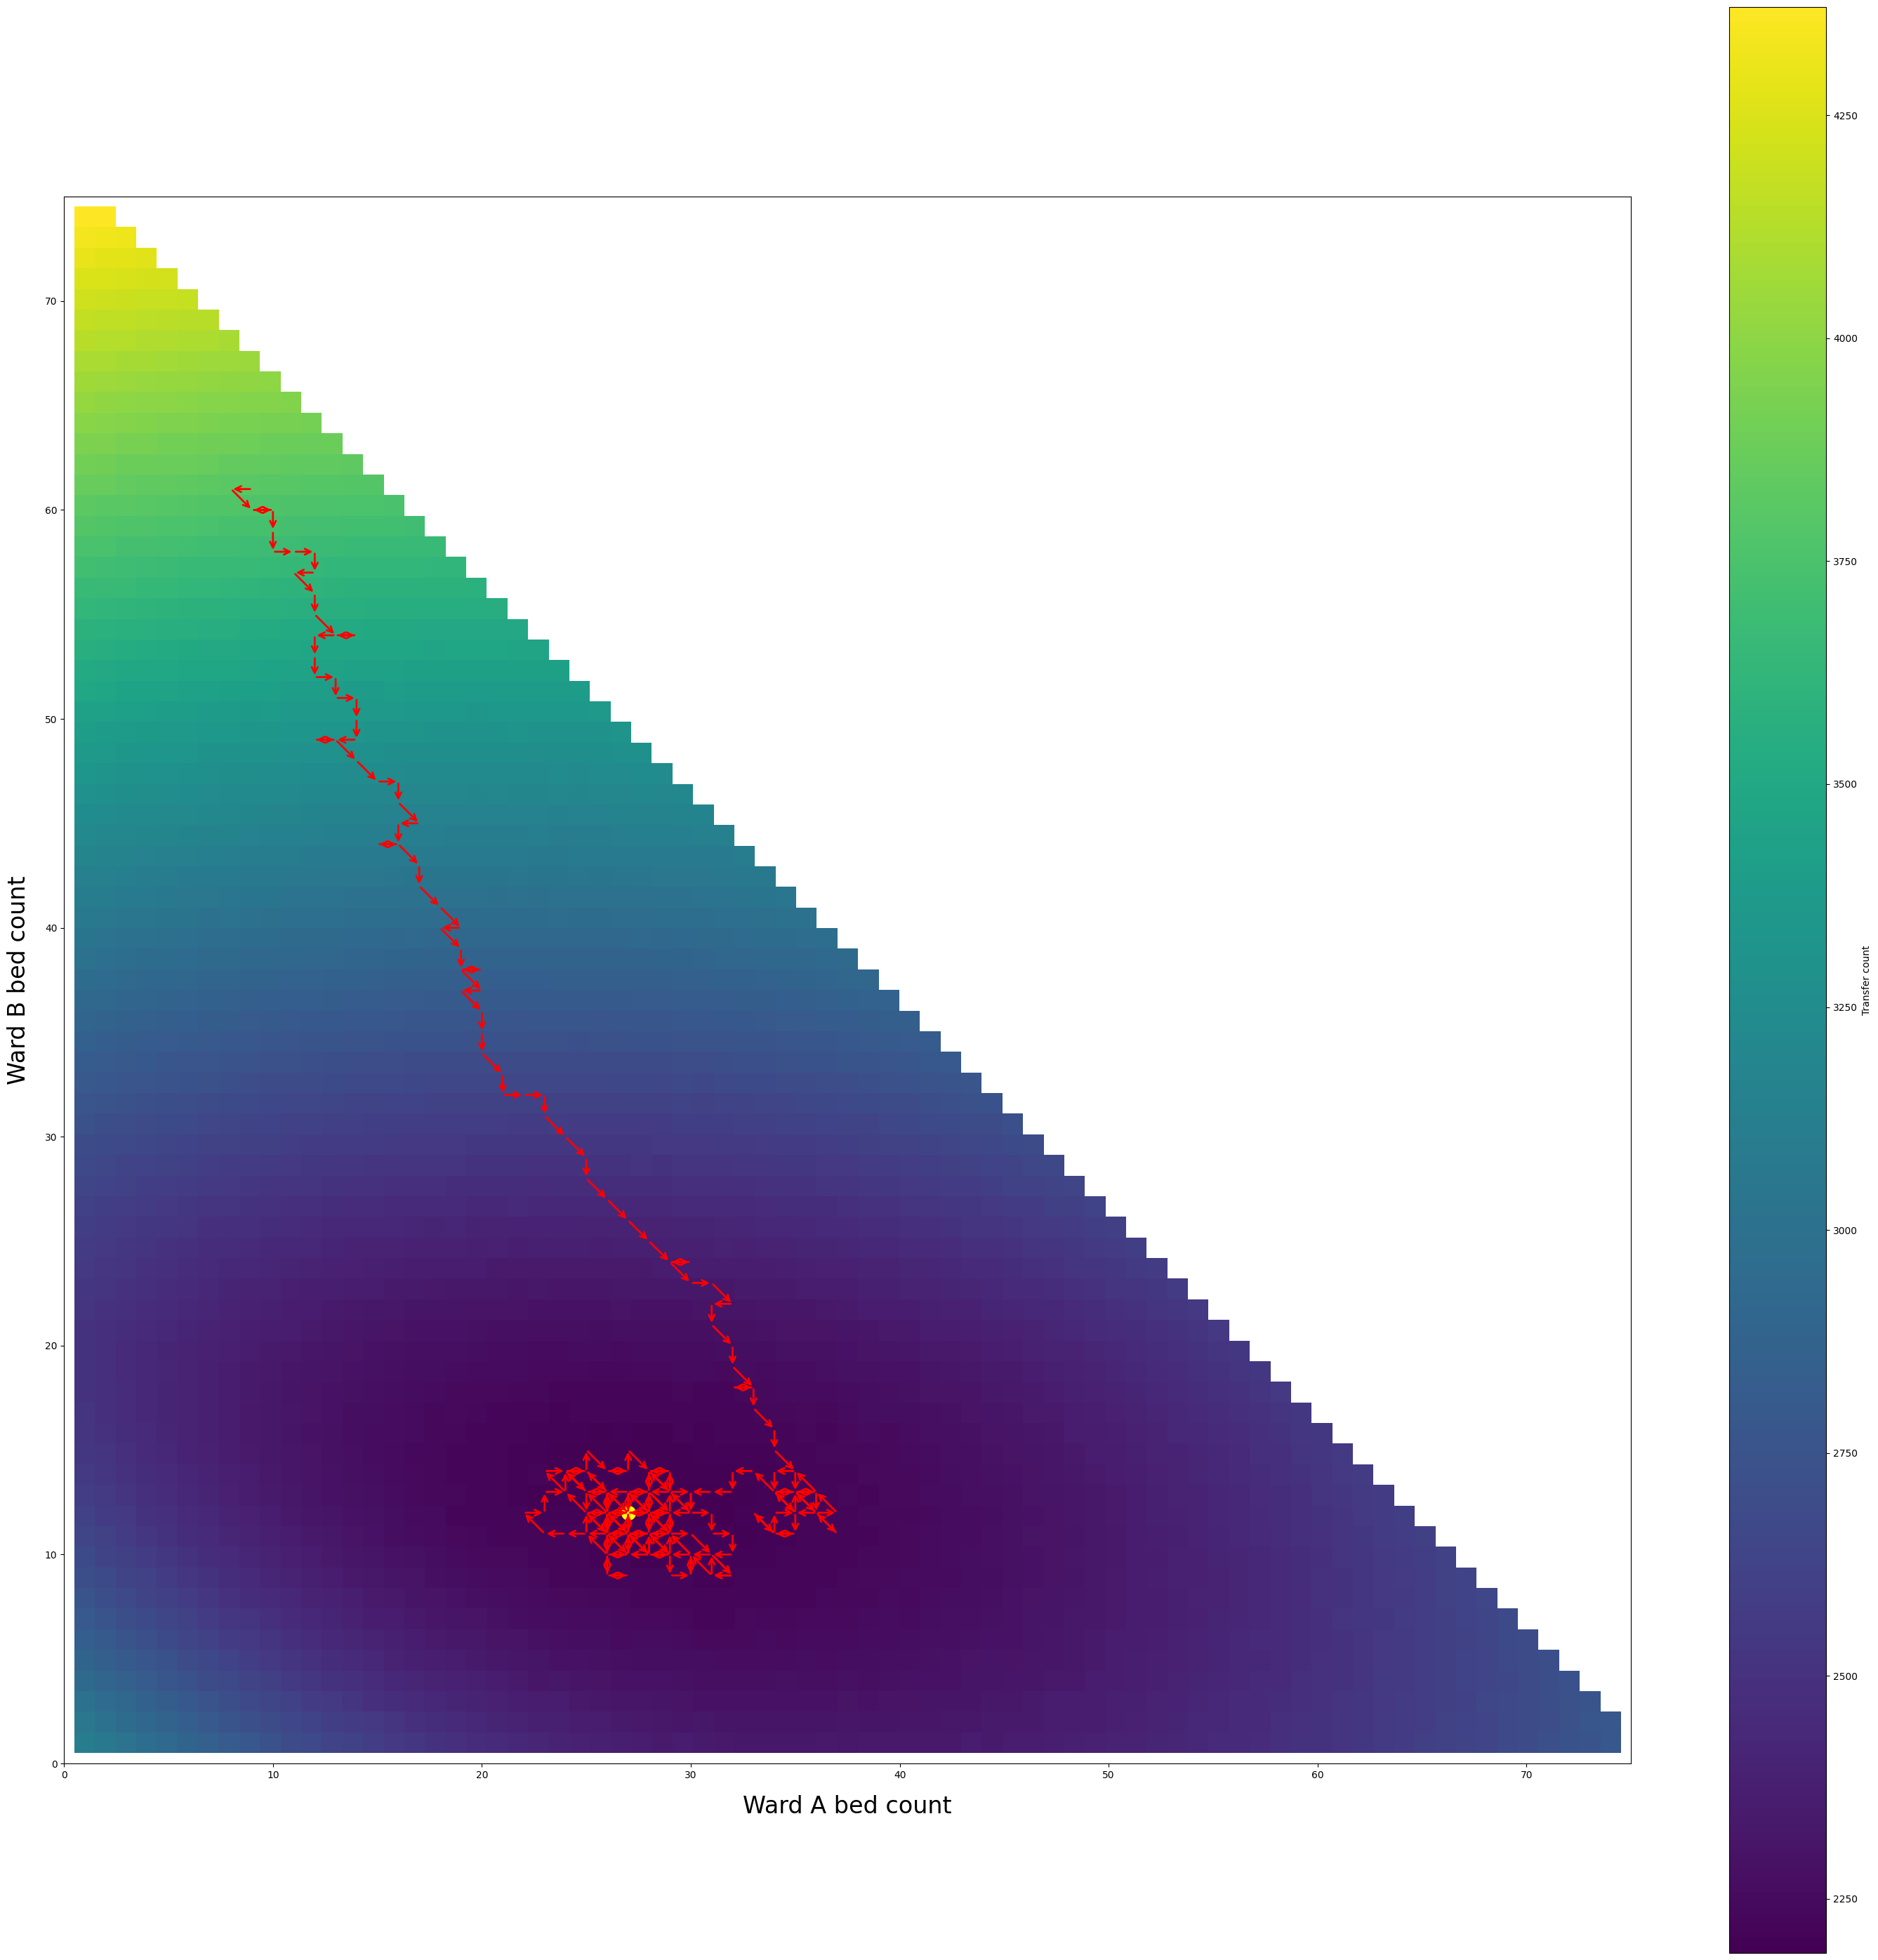

In [41]:
print(x)
print(min)
print(xmin)
print(ymin)
print(zmin)


plt.figure(figsize=(36, 36))

# Display the matrix. Z[j, i] maps correctly when origin='lower'
heatmap = plt.imshow(Z, extent=[0.5, max_val + 0.5, 0.5, max_val + 0.5], 
                     origin='lower', cmap='viridis', aspect='equal')

# Add colorbar, labels, and title
plt.colorbar(heatmap, label='Transfer count')

# Show constraint boundary line
for i in range(len(pathx) - 1):
    plt.annotate('', 
                 xy=(pathx[i+1], pathy[i+1]),      # Where the arrow points (Next point)
                 xytext=(pathx[i], pathy[i]),      # Where the arrow starts (Current point)
                 arrowprops=dict(arrowstyle="->", color="red", lw=2, mutation_scale=15))

#plt.scatter(pathx, pathy)
plt.scatter(27,12, color = "yellow", s = 200)
plt.xlabel('Ward A bed count', fontsize=24, labelpad=15)
plt.ylabel('Ward B bed count', fontsize=24, labelpad=15)

plt.xlim(0, 75)
plt.ylim(0, 75)

plt.show()
